In [1]:
import pandas as pd                                        # DataFrame operations
import numpy as np                                         # numerical operations
from sklearn.feature_extraction.text import CountVectorizer      # builds DTM from text
from sklearn.feature_extraction.text import TfidfVectorizer      # builds TF-IDF matrix
from sklearn.decomposition import TruncatedSVD             # dimensionality reduction (LSA)
from sklearn.preprocessing import Normalizer              # L2 normalize SVD output
import matplotlib.pyplot as plt                            # plotting
import seaborn as sns                                      # prettier plots
import scipy.sparse                                        # for inspecting sparse matrices

Load clean data

In [2]:
# Load the preprocessed sessions DataFrame from Phase 2
df = pd.read_csv("../data/processed/sessions_clean.csv")  # read clean data

print(f"Loaded {len(df)} sessions")                        # confirm row count
print(f"Columns: {list(df.columns)}")                      # show available columns
print(df[['child_id', 'age_months', 'text_clean']].head(3))  # preview

Loaded 214 sessions
Columns: ['file_id', 'child_id', 'age_months', 'n_utterances', 'n_tokens', 'mlu', 'ttr', 'text', 'text_clean', 'text_no_lemma', 'text_with_stops', 'n_raw', 'n_clean', 'n_with_stops', 'n_no_lemma']
  child_id  age_months                                         text_clean
0     Adam       27.13  play checker big drum big drum big drum big dr...
1     Adam       27.60  okay suitcase suitcase spaghetti monroe suitca...
2     Adam       28.10  yeah train water water right water jack jill c...


Build the DTM with CountVectorizer

In [ ]:
# Initialize CountVectorizer with frequency cutoffs
# min_df=2: ignore words that appear in fewer than 2 sessions (too rare, just noise)
# max_df=0.95: ignore words that appear in more than 95% of sessions (too common, no signal)
vectorizer_counts = CountVectorizer(
    ngram_range=(1, 2),                                      # unigrams and bigrams
    min_df=2,                                              # minimum document frequency
    max_df=0.95                                            # maximum document frequency
)

# fit_transform on text_clean:
# fit   = learn the vocabulary from all sessions
# transform = convert each session into a vector of word counts
DTM = vectorizer_counts.fit_transform(df['text_clean'])    # returns sparse matrix

# Inspect the DTM shape: (n_sessions, n_vocabulary_terms)
print(f"DTM shape: {DTM.shape}")                           # should be (214, ~vocab_size)
print(f"Vocabulary size: {len(vectorizer_counts.vocabulary_)}")  # unique words kept

# Show first 10 words in the vocabulary (alphabetically sorted)
vocab = vectorizer_counts.get_feature_names_out()          # array of all vocabulary words
print(f"\nFirst 10 vocab words: {vocab[:10]}")             # preview vocabulary
print(f"Last 10 vocab words:  {vocab[-10:]}")              # preview end of vocabulary

DTM shape: (214, 17196)
Vocabulary size: 17196

First 10 vocab words: ['abc' 'abc tell' 'accident' 'accident accident' 'accident put'
 'accident yeah' 'ache' 'across' 'across street' 'act']
Last 10 vocab words:  ['zero one' 'zero zero' 'zip' 'zip zip' 'zipper' 'zipper zipper' 'zoo'
 'zoo yeah' 'zoo zoo' 'zoom']


Understand DTM Sparsity

In [5]:
# A DTM is almost always a SPARSE matrix — most sessions don't use most words
# Sparsity = fraction of cells that are zero
total_cells = DTM.shape[0] * DTM.shape[1]                 # total number of cells
non_zero    = DTM.nnz                                      # number of non-zero cells
sparsity    = 1 - (non_zero / total_cells)                 # fraction that are zero

print(f"Total cells:     {total_cells:,}")                 # rows × columns
print(f"Non-zero cells:  {non_zero:,}")                    # actual word counts stored
print(f"Sparsity:        {sparsity:.1%}")                  # expect >90% sparse

Total cells:     3,679,944
Non-zero cells:  95,940
Sparsity:        97.4%


Effect of min_df Cutoff

min_df | Vocabulary Size
-------|----------------
    1  |  70,121
    2  |  17,196
    5  |  4,214
   10  |  1,714


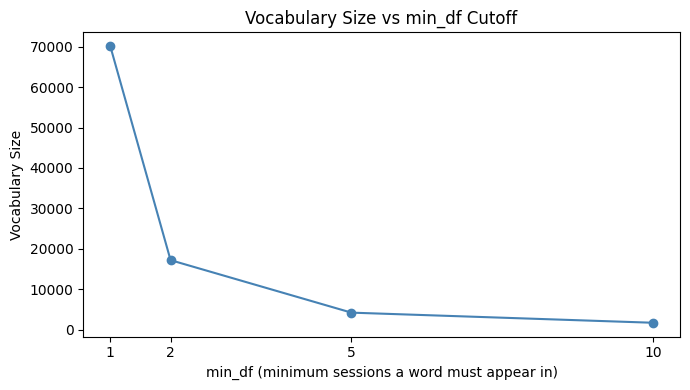

In [14]:
# Test 3 different min_df values to show the tradeoff
cutoffs   = [1, 2, 5, 10]                                  # different minimum frequencies
vocab_sizes = []                                           # store resulting vocab sizes

for cutoff in cutoffs:                                     # loop over each cutoff value
    vec = CountVectorizer(ngram_range=(1, 2),min_df=cutoff, max_df=0.95)      # build vectorizer with this cutoff
    dtm = vec.fit_transform(df['text_clean'])              # fit and transform
    vocab_sizes.append(len(vec.vocabulary_))               # record vocabulary size

# Print the tradeoff table
print("min_df | Vocabulary Size")
print("-------|----------------")
for c, v in zip(cutoffs, vocab_sizes):                     # loop and print each row
    print(f"  {c:3d}  |  {v:,}")

# Plot the tradeoff
plt.figure(figsize=(7, 4))                                 # figure size
plt.plot(cutoffs, vocab_sizes, marker='o', color='steelblue')  # line + dot per cutoff
plt.xlabel('min_df (minimum sessions a word must appear in)')  # x axis
plt.ylabel('Vocabulary Size')                              # y axis
plt.title('Vocabulary Size vs min_df Cutoff')             # title
plt.xticks(cutoffs)                                        # show all cutoff values on x axis
plt.tight_layout()                                         # clean layout
plt.savefig('../figures/mindf_vocabulary_tradeoff.png', dpi=150, bbox_inches='tight')  # save
plt.show()                                                 # display

Build TF-IDF Matrix

In [15]:
# TfidfVectorizer applies TF-IDF weighting directly
# sublinear_tf=True: use log(1+tf) instead of raw tf (dampens effect of very frequent words)
vectorizer_tfidf = TfidfVectorizer(
    ngram_range=(1, 2),                                      # unigrams and bigrams
    min_df=2,                                              # same cutoffs as CountVectorizer
    max_df=0.95,                                           # for fair comparison
    sublinear_tf=True                                      # log normalization of term freq
)

# fit_transform: learn vocabulary AND compute TF-IDF weights in one step
TFIDF = vectorizer_tfidf.fit_transform(df['text_clean'])  # returns sparse matrix

print(f"TF-IDF matrix shape: {TFIDF.shape}")              # same shape as DTM
print(f"Vocabulary size: {len(vectorizer_tfidf.vocabulary_)}")  # should match DTM vocab

TF-IDF matrix shape: (214, 17196)
Vocabulary size: 17196


Compare DTM vs TF-IDF for One Session

In [16]:
# Get vocabulary for reference
vocab_tfidf = vectorizer_tfidf.get_feature_names_out()     # all vocabulary words

# Pick session 0 (Adam, ~27 months) as example
session_idx = 0                                            # index of session to inspect

# Get raw counts and TF-IDF weights for this session
counts_row = DTM[session_idx].toarray().flatten()          # convert sparse row to array
tfidf_row  = TFIDF[session_idx].toarray().flatten()        # convert sparse row to array

# Build a comparison DataFrame for the top words
comparison = pd.DataFrame({
    'word'   : vocab_tfidf,                                # vocabulary word
    'count'  : counts_row,                                 # raw count in this session
    'tfidf'  : tfidf_row                                   # TF-IDF weight in this session
})

# Show top 10 words by raw count
print("=== Top 10 words by RAW COUNT ===")
print(comparison.sort_values('count', ascending=False).head(10)[['word','count','tfidf']])

# Show top 10 words by TF-IDF weight
print("\n=== Top 10 words by TF-IDF WEIGHT ===")
print(comparison.sort_values('tfidf', ascending=False).head(10)[['word','count','tfidf']])

=== Top 10 words by RAW COUNT ===
            word  count     tfidf
8993       mommy     75  0.030565
10216       okay     66  0.039888
11          adam     64  0.069813
7143       kitty     48  0.070484
2925       daddy     45  0.036570
16441      write     40  0.039601
10805      paper     39  0.042558
1449        bozo     39  0.071175
1668   bulldozer     34  0.083705
16578       yeah     30  0.024484

=== Top 10 words by TF-IDF WEIGHT ===
                word  count     tfidf
14401         tattoo     12  0.089276
2963      daddy name     11  0.087047
12031    read shadow      9  0.086633
15213          tuffy     12  0.085279
9694      name daddy     10  0.084605
13094         shadow     30  0.084411
6962            john     13  0.083897
1668       bulldozer     34  0.083705
6414        hit ball     11  0.083150
13098  shadow shadow     13  0.081072


Apply SVD (LSA — Latent Semantic Analysis):

- SVD compresses the high-dimensional TF-IDF matrix into ~50 dimensions. This is the step that discovers latent structure without using age as input.

In [17]:
# Number of SVD components to keep
# 50 is a standard starting point — captures main variance without overfitting
N_COMPONENTS = 50                                          # number of latent dimensions

# TruncatedSVD is the sklearn implementation of LSA
# It finds the k directions of maximum variance in the TF-IDF matrix
svd = TruncatedSVD(n_components=N_COMPONENTS, random_state=42)  # random_state for reproducibility

# fit_transform: learn the SVD decomposition AND project data into reduced space
SVD_matrix = svd.fit_transform(TFIDF)                     # shape: (214, 50)

print(f"SVD matrix shape: {SVD_matrix.shape}")            # (n_sessions, n_components)

# How much variance does each component explain?
explained = svd.explained_variance_ratio_                 # fraction of variance per component
print(f"\nVariance explained by first 5 components:")
for i, v in enumerate(explained[:5]):                     # show first 5
    print(f"  SVD component {i+1}: {v:.3f} ({v*100:.1f}%)")

print(f"\nTotal variance explained by {N_COMPONENTS} components: {explained.sum():.3f} ({explained.sum()*100:.1f}%)")

SVD matrix shape: (214, 50)

Variance explained by first 5 components:
  SVD component 1: 0.003 (0.3%)
  SVD component 2: 0.019 (1.9%)
  SVD component 3: 0.016 (1.6%)
  SVD component 4: 0.015 (1.5%)
  SVD component 5: 0.010 (1.0%)

Total variance explained by 50 components: 0.330 (33.0%)


Normalize SVD Output

In [18]:
# After SVD, normalize each row to unit length (L2 normalization)
# This ensures cosine similarity works correctly downstream
# (as taught in Session 4 — cosine similarity requires normalized vectors)
normalizer  = Normalizer(norm='l2')                        # L2 = Euclidean normalization
SVD_normed  = normalizer.fit_transform(SVD_matrix)         # apply to all rows

print(f"Normalized SVD matrix shape: {SVD_normed.shape}")  # same shape, normalized rows

# Verify normalization: each row should now have length = 1.0
row_norms = np.linalg.norm(SVD_normed, axis=1)             # compute norm of each row
print(f"Row norm min: {row_norms.min():.4f}")              # should be 1.0
print(f"Row norm max: {row_norms.max():.4f}")              # should be 1.0

Normalized SVD matrix shape: (214, 50)
Row norm min: 1.0000
Row norm max: 1.0000


In [19]:
# Save enriched DataFrame with SVD columns
df.to_csv("../data/processed/sessions_features.csv", index=False)  # save to processed

# Save the full SVD matrix as numpy array (all 50 dimensions)
np.save("../data/processed/SVD_matrix.npy", SVD_normed)   # save as .npy binary

print("Saved sessions_features.csv and SVD_matrix.npy")
print(f"Final DataFrame shape: {df.shape}")                # confirm

Saved sessions_features.csv and SVD_matrix.npy
Final DataFrame shape: (214, 15)
